# Multi-Agent Target Tracking via a Time-Expanded Cellular Sheaf

This example uses a time-expanded sheaf to study how coordination constraints
determine the space of feasible agent trajectories.  Five scenarios are compared;
the nullspace dimension of the restricted sheaf Laplacian measures how many
free degrees of freedom remain after constraints are imposed.

**Vehicle model.** Each agent or target is a planar quadrotor.  The state is
$$
x = [y,\, z,\, \varphi,\, \dot y,\, \dot z,\, \dot\varphi]^\top \in \mathbb{R}^6
$$
where $y$ is the lateral position, $z$ is the altitude, and $\varphi$ is
the roll angle.  The control input is $u = [T_1, T_2]^\top \in \mathbb{R}^2$.

**Sheaf structure.** Each vertex $(\text{entity}, t)$ carries a stalk
$\mathbb{R}^{n_x + n_u} = \mathbb{R}^8$.  Three edge families encode:
1. *Dynamics*: $x_{t+1} = A_d x_t + B_d u_t$.
2. *Consensus*: inter-agent agreement on a chosen coordinate subspace.
3. *Tracking*: agent–target alignment in a chosen coordinate subspace.

By varying which coordinates are constrained and at which timesteps, we obtain
four qualitatively different solution spaces whose nullspace dimensions tell
the story of the engineering constraints.

The problem-construction and solve utilities used below come from
`CellularSheaves.ControlSheaves.MultiAgentTracking`.

- Problem specification is written with `@tracking_problem` from
  `CellularSheaves.ControlSheaves.TrackingDSL`.
- The solver pipeline is `lower_tracking_program -> run_scenario`.
- Animations are produced by `animate_tracking_xy`, implemented by the plotting
  extension when `Plots` is loaded.

In [1]:
using CellularSheaves
using CellularSheaves.ControlSheaves.MultiAgentTracking
using CellularSheaves.ControlSheaves.TrackingDSL
using CellularSheaves.TrajectorySheaves: continuous_to_discrete_zoh
using LinearAlgebra
using Plots

## Planar Quadrotor Dynamics

State: $x = [y, z, \varphi, \dot y, \dot z, \dot\varphi]$.
The linearisation is taken around the hover trim condition.

In [2]:
g     = 9.81
m_veh = 0.5
I_quad = 0.01
ell   = 0.25

Ac = [0.0  0.0   0.0   1.0  0.0  0.0;
      0.0  0.0   0.0   0.0  1.0  0.0;
      0.0  0.0   0.0   0.0  0.0  1.0;
      0.0  0.0  -g     0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0]

Bc = [0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      1.0 / m_veh       1.0 / m_veh;
      ell / (2I_quad)  -ell / (2I_quad)]

h = 0.05
Ad, Bd = continuous_to_discrete_zoh(Ac, Bc, h)
nx = size(Ad, 1)
nu = size(Bd, 2)

2

State-index constants for the planar quadrotor.

In [3]:
IDX_Y   = 1   # lateral position y
IDX_Z   = 2   # altitude z
IDX_PHI = 3   # roll angle φ
IDX_YDT = 4   # ẏ
IDX_ZDT = 5   # ż
IDX_PHIDT = 6   # roll angle ϕ̇

6

## Common Setup

All five scenarios use two agents and two targets over a 40-step horizon (2 s).
The projection matrices are defined once and reused:

- $R_{yz}$: projects the $(n_x + n_u)$-stalk onto $(y, z)$ (Scenario 1).
- $R_y$: projects onto $y$ only (consensus in Scenarios 2–4).
- $R_z$: projects onto $z$ only (tracking in Scenarios 2–4).
- $negR_y$: negative $y$ projection used for mirrored consensus (Scenario 5).

Each scenario is specified as a `@tracking_problem` DSL program.
The DSL declaratively names agents, targets, a time horizon, and the
consensus/tracking coordination edges.  Calling `lower_tracking_program`
on the resolved program produces the `TrackingProblem` struct used by the
simulation utilities.  The boundary data (initial conditions, target
trajectories) is still supplied externally as a plain `Dict` — it varies
per scenario but never changes the sheaf topology.

In [4]:
k         = 40
times     = h .* collect(0:k)

R_yz = state_projection_matrix([IDX_Y, IDX_Z], nx, nu)
R_y  = state_projection_matrix([IDX_Y],         nx, nu)
R_z  = state_projection_matrix([IDX_Z],         nx, nu)
negR_y = -R_y

1×8 Matrix{Float64}:
 -1.0  -0.0  -0.0  -0.0  -0.0  -0.0  -0.0  -0.0

Bobbing targets used in Scenarios 2–5.
Both complete two full vertical cycles over the 2-second horizon.

In [5]:
omega_2periods = 2π * 2 / (k * h)
bt1 = BobbingTarget(0.0, 1.0, 0.3, omega_2periods)
bt2 = BobbingTarget(0.0, 2.0, 0.3, omega_2periods)
traj_bt1 = trajectory(bt1, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)
traj_bt2 = trajectory(bt2, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

41-element Vector{Vector{Float64}}:
 [0.0, 2.0, 0.0, 0.0, 1.8849555921538759, 0.0, 0.0, 0.0]
 [0.0, 2.0927050983124844, 0.0, 0.0, 1.7926992988449335, 0.0, 0.0, 0.0]
 [0.0, 2.176335575687742, 0.0, 0.0, 1.524961107694578, 0.0, 0.0, 0.0]
 [0.0, 2.2427050983124843, 0.0, 0.0, 1.107949098294274, 0.0, 0.0, 0.0]
 [0.0, 2.285316954888546, 0.0, 0.0, 0.58248331161764, 0.0, 0.0, 0.0]
 [0.0, 2.3, 0.0, 0.0, 1.1542024162330739e-16, 0.0, 0.0, 0.0]
 [0.0, 2.285316954888546, 0.0, 0.0, -0.5824833116176402, 0.0, 0.0, 0.0]
 [0.0, 2.2427050983124843, 0.0, 0.0, -1.107949098294274, 0.0, 0.0, 0.0]
 [0.0, 2.176335575687742, 0.0, 0.0, -1.5249611076945777, 0.0, 0.0, 0.0]
 [0.0, 2.0927050983124844, 0.0, 0.0, -1.7926992988449335, 0.0, 0.0, 0.0]
 ⋮
 [0.0, 1.8236644243122582, 0.0, 0.0, -1.5249611076945784, 0.0, 0.0, 0.0]
 [0.0, 1.757294901687516, 0.0, 0.0, -1.1079490982942746, 0.0, 0.0, 0.0]
 [0.0, 1.7146830451114539, 0.0, 0.0, -0.5824833116176374, 0.0, 0.0, 0.0]
 [0.0, 1.7, 0.0, 0.0, -8.079416913631517e-16, 0.0, 0.0

Build boundary data with pinned agent initials (and optional terminal states)
plus pinned target trajectories.

In [6]:
function build_boundary(
    prob,
    nu::Int;
    agent_initials::Vector{Vector{Float64}},
    target_trajs::Vector{Vector{Vector{Float64}}},
    agent_terminals::Union{Nothing,Vector{Vector{Float64}}}=nothing,
)
    bnd = Dict{Int,Vector{Float64}}()

    for (i, x0) in enumerate(agent_initials)
        bnd[agent_vertex(prob, i, 0)] = vcat(x0, zeros(nu))
    end

    if !isnothing(agent_terminals)
        for (i, xk) in enumerate(agent_terminals)
            bnd[agent_vertex(prob, i, k)] = vcat(xk, zeros(nu))
        end
    end

    for (j, traj) in enumerate(target_trajs)
        for (t, x) in enumerate(traj)
            bnd[target_vertex(prob, j, t - 1)] = x
        end
    end

    return bnd
end

build_boundary (generic function with 1 method)

## Scenario 1: Full (y,z) Coordination at Every Timestep

Both consensus and tracking edges use the $(y, z)$ projection, active at
**every** timestep.

The two agents travel to distinct goals while each tracking its own target in
full $(y, z)$.  But the consensus edge demands that agents agree in $(y, z)$
at every step.  Since the two targets travel *different* $(y, z)$
trajectories, the constraints "A1 tracks T1", "A2 tracks T2", and
"A1 agrees with A2 in $(y,z)$" are **mutually incompatible** unless the
targets coincide.  The harmonic extension therefore computes a least-squares
compromise and typically reports a relatively large residual.

In [7]:
x0_a1_s1 = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
xk_a1_s1 = [2.0, 1.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s1 = [0.0, 2.0, 0.0, 0.0, 0.0, 0.0]
xk_a2_s1 = [2.0, 2.5, 0.0, 0.0, 0.0, 0.0]

traj_t1_s1 = generate_reference_trajectory(x0_a1_s1, xk_a1_s1, k, Ad, Bd, nx, nu)
traj_t2_s1 = generate_reference_trajectory(x0_a2_s1, xk_a2_s1, k, Ad, Bd, nx, nu)

41-element Vector{Vector{Float64}}:
 [0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [-6.657028086328592e-11, 1.999999999998913, 1.9363954883999668e-12, -5.822051174497744e-12, -2.842170943040401e-14, 2.3092638912203256e-14, -203.2584543511764, -185.9205690752912]
 [0.0005536608514288091, 1.027052441431656, -0.27090445743387137, 0.04429287878147222, -38.917902342646755, -10.83617829742823, 210.29543195025158, 194.70112525846122]
 [0.007806932318043341, 0.0936487173200129, -0.5690523302465679, 0.27021157114915156, 1.5817533782246027, -1.089736615059234, 0.0, 0.21580227185841544]
 [0.028525121271361763, 0.1732758919098019, -0.6269110714966014, 0.5632459417478088, 1.6033336054105787, -1.2246130349707305, 1.5973336544345829, 0.0]
 [0.06457418699142722, 0.2574359063153301, -0.6631833848910234, 0.8816819513453991, 1.7630669708542257, -0.22627950094920382, 0.0, 0.3812678154255664]
 [0.11684899187388731, 0.34654242439551813, -0.6804546695464427, 1.2107221741478762, 1.8011937523970252, -0.46457188559

The DSL program below declares agents, targets, the time horizon, and the
$(y,z)$ consensus and tracking edges active at every timestep.
`lower_tracking_program` builds the `TrackingProblem` with target dynamics
included and a higher tracking weight to steer the least-squares solution
toward the tracking objective.

In [8]:
prog1 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    times(Tall = 0:K)
    consensus(c1; agents=(a1,a2), maps=(R_yz,R_yz), at=Tall)
    track(tr1; agent=a1, target=t1, maps=(R_yz,R_yz), at=Tall)
    track(tr2; agent=a2, target=t2, maps=(R_yz,R_yz), at=Tall)
end
ctx1 = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_yz => R_yz, :h => h)
prob1 = lower_tracking_program(prog1, ctx1;
    include_target_dynamics=true, tracking_weight=5.0,
).problem

bnd1 = build_boundary(prob1, nu;
    agent_initials=[x0_a1_s1, x0_a2_s1],
    agent_terminals=[xk_a1_s1, xk_a2_s1],
    target_trajs=[traj_t1_s1, traj_t2_s1],
)

result1 = run_scenario("Scenario 1", prob1, bnd1, times;
    target_trajs = [traj_t1_s1, traj_t2_s1], y_col = IDX_Y, z_col = IDX_Z)

animate_tracking_xy(result1; filename="quadrotor_scenario1.gif", x_col=IDX_Y, y_col=IDX_Z)

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/quadrotor_scenario1.gif


Plots.Animation("/tmp/jl_K78yC7", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000032.png", "000033.png", "000034.png", "000035.png", "000036.png", "000037.png", "000038.png", "000039.png", "000040.png", "000041.png"])

![Scenario 1 animation](quadrotor_scenario1.gif)

## Scenario 2: y-Consensus and z-Tracking, All Timesteps, Aligned Initial Conditions

Targets bob vertically.  Consensus edges constrain agents to agree only on
**lateral position** $y$; tracking edges constrain each agent to match its
assigned target in **altitude** $z$.  Both edge families are active at every
timestep.

Because the two targets share $y = 0$ and the consensus only constrains $y$,
the system is consistent: agents can agree in $y$ while independently tracking
different altitudes.  A non-trivial nullspace often arises because
$z$ (and all other state components) remain unconstrained by the consensus
edges.

Since all target vertices are pinned as boundary data, target dynamics edges
are omitted (`include_target_dynamics = false`).

The DSL program uses split projection matrices: $R_y$ for consensus (lateral
agreement) and $R_z$ for tracking (altitude following).  Both edge families
span every timestep (`at=Tall`).  Target dynamics are excluded because all
target vertices will be pinned as boundary conditions.

In [9]:
prog2 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    times(Tall = 0:K)
    consensus(c1; agents=(a1,a2), maps=(R_y,R_y), at=Tall)
    track(tr1; agent=a1, target=t1, maps=(R_z,R_z), at=Tall)
    track(tr2; agent=a2, target=t2, maps=(R_z,R_z), at=Tall)
end
ctx2 = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_y => R_y, :R_z => R_z, :h => h)
prob2 = lower_tracking_program(prog2, ctx2;
    tracking_weight=5.0,
).problem

x0_a1_s2 = [0.0, traj_bt1[1][IDX_Z], 0.0, 0.0, traj_bt1[1][IDX_ZDT], 0.0]
x0_a2_s2 = [0.0, traj_bt2[1][IDX_Z], 0.0, 0.0, traj_bt2[1][IDX_ZDT], 0.0]

bnd2 = build_boundary(prob2, nu;
    agent_initials=[x0_a1_s2, x0_a2_s2],
    target_trajs=[traj_bt1, traj_bt2],
)

result2 = run_scenario("Scenario 2", prob2, bnd2, times;
    target_trajs = [traj_bt1, traj_bt2], y_col = IDX_Y, z_col = IDX_Z)

animate_tracking_xy(result2; filename="quadrotor_scenario2.gif", x_col=IDX_Y, y_col=IDX_Z)

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/quadrotor_scenario2.gif


Plots.Animation("/tmp/jl_r5gPcM", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000032.png", "000033.png", "000034.png", "000035.png", "000036.png", "000037.png", "000038.png", "000039.png", "000040.png", "000041.png"])

![Scenario 2 animation](quadrotor_scenario2.gif)

## Scenario 3: y-Consensus and z-Tracking at the Last Timestep Only

The same projection matrices as Scenario 2, but coordination edges are
active **only at** $t = k$.  Agents evolve freely (dynamics only) for
$t = 0, \ldots, k-1$ and must converge to the terminal constraint.

Both targets share $y = 0$ (laterally aligned), but agents start misaligned
with each other and with the targets in both $y$ and $z$.
Removing $k$ timesteps of coordination edges dramatically enlarges the
feasible space (null dim >> Scenario 2).

Changing `at=Tall` to `at=t[end]` in the DSL restricts both the consensus and
tracking edges to the single terminal timestep `t = k`.  The only topological
difference from Scenario 2 is this single keyword change.

In [10]:
prog3 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    consensus(c1; agents=(a1,a2), maps=(R_y,R_y), at=t[end])
    track(tr1; agent=a1, target=t1, maps=(R_z,R_z), at=t[end])
    track(tr2; agent=a2, target=t2, maps=(R_z,R_z), at=t[end])
end
ctx3 = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_y => R_y, :R_z => R_z, :h => h)
prob3 = lower_tracking_program(prog3, ctx3;
    tracking_weight=5.0,
).problem

x0_a1_s3 = [-0.5, 0.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s3 = [ 1.0, 1.5, 0.0, 0.0, 0.0, 0.0]

bnd3 = build_boundary(prob3, nu;
    agent_initials=[x0_a1_s3, x0_a2_s3],
    target_trajs=[traj_bt1, traj_bt2],
)

result3 = run_scenario("Scenario 3", prob3, bnd3, times;
    target_trajs = [traj_bt1, traj_bt2], y_col = IDX_Y, z_col = IDX_Z)

animate_tracking_xy(result3; filename="quadrotor_scenario3.gif", x_col=IDX_Y, y_col=IDX_Z)

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/quadrotor_scenario3.gif


Plots.Animation("/tmp/jl_1py07z", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000032.png", "000033.png", "000034.png", "000035.png", "000036.png", "000037.png", "000038.png", "000039.png", "000040.png", "000041.png"])

![Scenario 3 animation](quadrotor_scenario3.gif)

## Scenario 4: Windowed Late-Horizon Coordination with Offset Target

This scenario changes both boundary data and constraint timing:

- Target 2 is shifted to $y = 1.5$ m.
- Consensus is active on a tail window (`T_tail = K_tail:K`).
- Tracking is active on `10:K`.

Unlike Scenario 3, this is a different coordination architecture, so changes in
nullspace dimension are expected and interpreted as structural changes, not only
trajectory-level effects.

In [11]:
bt2_s4 = BobbingTarget(1.5, 2.0, 0.3, omega_2periods)
traj_bt2_s4 = trajectory(bt2_s4, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

41-element Vector{Vector{Float64}}:
 [1.5, 2.0, 0.0, 0.0, 1.8849555921538759, 0.0, 0.0, 0.0]
 [1.5, 2.0927050983124844, 0.0, 0.0, 1.7926992988449335, 0.0, 0.0, 0.0]
 [1.5, 2.176335575687742, 0.0, 0.0, 1.524961107694578, 0.0, 0.0, 0.0]
 [1.5, 2.2427050983124843, 0.0, 0.0, 1.107949098294274, 0.0, 0.0, 0.0]
 [1.5, 2.285316954888546, 0.0, 0.0, 0.58248331161764, 0.0, 0.0, 0.0]
 [1.5, 2.3, 0.0, 0.0, 1.1542024162330739e-16, 0.0, 0.0, 0.0]
 [1.5, 2.285316954888546, 0.0, 0.0, -0.5824833116176402, 0.0, 0.0, 0.0]
 [1.5, 2.2427050983124843, 0.0, 0.0, -1.107949098294274, 0.0, 0.0, 0.0]
 [1.5, 2.176335575687742, 0.0, 0.0, -1.5249611076945777, 0.0, 0.0, 0.0]
 [1.5, 2.0927050983124844, 0.0, 0.0, -1.7926992988449335, 0.0, 0.0, 0.0]
 ⋮
 [1.5, 1.8236644243122582, 0.0, 0.0, -1.5249611076945784, 0.0, 0.0, 0.0]
 [1.5, 1.757294901687516, 0.0, 0.0, -1.1079490982942746, 0.0, 0.0, 0.0]
 [1.5, 1.7146830451114539, 0.0, 0.0, -0.5824833116176374, 0.0, 0.0, 0.0]
 [1.5, 1.7, 0.0, 0.0, -8.079416913631517e-16, 0.0, 0.0

The DSL program below introduces explicit named time sets for the late-horizon
consensus and delayed tracking windows.

In [12]:
prog4 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    time(K_tail = 30)
    times(T_tail = K_tail:K)
    consensus(c1; agents=(a1,a2), maps=(R_y,R_y), at=T_tail)
    track(tr1; agent=a1, target=t1, maps=(R_z,R_z), at=10:t[end])
    track(tr2; agent=a2, target=t2, maps=(R_z,R_z), at=10:t[end])
end
ctx4 = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_y => R_y, :R_z => R_z, :h => h)
prob4 = lower_tracking_program(prog4, ctx4;
    tracking_weight=5.0,
).problem

x0_a1_s4 = [-0.5, 0.5, 0.0, 0.0, 0.0, 0.0]
x0_a2_s4 = [ 1.0, 1.5, 0.0, 0.0, 0.0, 0.0]

bnd4 = build_boundary(prob4, nu;
    agent_initials=[x0_a1_s4, x0_a2_s4],
    target_trajs=[traj_bt1, traj_bt2_s4],
)

result4 = run_scenario("Scenario 4", prob4, bnd4, times;
    target_trajs = [traj_bt1, traj_bt2_s4], y_col = IDX_Y, z_col = IDX_Z)

animate_tracking_xy(result4; filename="quadrotor_scenario4.gif", x_col=IDX_Y, y_col=IDX_Z)

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/quadrotor_scenario4.gif


Plots.Animation("/tmp/jl_fUzGUO", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000032.png", "000033.png", "000034.png", "000035.png", "000036.png", "000037.png", "000038.png", "000039.png", "000040.png", "000041.png"])

![Scenario 4 animation](quadrotor_scenario4.gif)

## Scenario 5: Tracking compound requirements

This scenario matches scenario 4 but requires the second agent to track in y and z.
The consensus edge forces alignment in y.

In [13]:
prog5 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    time(K_tail = 30)
    times(T_tail = K_tail:K)
    times(Tall = 0:K)
    consensus(c_mirror; agents=(a1,a2), maps=(R_y,R_y), at=T_tail)
    track(tr1; agent=a1, target=t1, maps=(R_z,R_z), at=10:t[end])
    track(tr2; agent=a2, target=t2, maps=(R_yz,R_yz), at=10:t[end])
end
ctx5 = Dict{Symbol,Any}(
    :K => k,
    :Ad => Ad,
    :Bd => Bd,
    :R_y => R_y,
    :R_yz => R_yz,
    :R_z => R_z,
    :h => h,
)
prob5 = lower_tracking_program(prog5, ctx5;
    tracking_weight=5.0,
).problem

x0_a1_s5 = [-1.0, traj_bt1[1][IDX_Z], 0.0, 0.0, traj_bt1[1][IDX_ZDT], 0.0]
x0_a2_s5 = [ 1.0, traj_bt2_s4[1][IDX_Z], 0.0, 0.0, traj_bt2_s4[1][IDX_ZDT], 0.0]

bnd5 = build_boundary(prob5, nu;
    agent_initials=[x0_a1_s5, x0_a2_s5],
    target_trajs=[traj_bt1, traj_bt2_s4],
)

result5 = run_scenario("Scenario 5", prob5, bnd5, times;
    target_trajs = [traj_bt1, traj_bt2_s4], y_col = IDX_Y, z_col = IDX_Z)

animate_tracking_xy(result5; filename="quadrotor_scenario5.gif", x_col=IDX_Y, y_col=IDX_Z)

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/quadrotor_scenario5.gif


Plots.Animation("/tmp/jl_v4dyP2", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000032.png", "000033.png", "000034.png", "000035.png", "000036.png", "000037.png", "000038.png", "000039.png", "000040.png", "000041.png"])

![Scenario 5 animation](quadrotor_scenario5.gif)

## Comparison: How Constraints Shape the Solution Space

The five scenarios are summarised below.  The nullspace dimension and
Laplacian residual $\|dz\|$ are displayed via the `ScenarioResult` show method.

| Scenario | Consensus | Tracking | Active timesteps | Initial alignment |
|----------|-----------|----------|-----------------|-------------------|
| 1 | $(y,z)$ | $(y,z)$ | all $0:k$ | distinct endpoints |
| 2 | $y$     | $z$     | all $0:k$ | aligned with targets |
| 3 | $y$     | $z$     | terminal $k$ | unaligned; targets share $y$ |
| 4 | $y$     | $z$     | consensus on $K_tail:K$, tracking on $10:K$ | unaligned; targets offset in $y$ |
| 5 | $y$ | $z, yz$ | same as 4 | same as 4 |

**Constraint density governs nullspace size.**
Scenario 1 is infeasible: the $(y,z)$ consensus edge forces agents to share
the same trajectory in the $yz$-plane, but tracking edges demand they follow
different targets.  The energy minimiser therefore finds a compromise, not an
exactly feasible trajectory.
Scenario 2 (only $y$ consensus + $z$ tracking, all timesteps) is consistent
and often admits a family of solutions because fewer coordinates per edge are
constrained.
Restricting constraints to selected timesteps (Scenarios 3–4) removes many
constraints and can substantially enlarge the solution space.

**Nullspace dimension is a topological invariant.**
Nullspace dimension is determined by the restricted Laplacian induced by the
chosen edge structure and time sets.  Holding the architecture fixed while
changing only boundary values changes trajectories but not this structural
dimension.  Changing timing sets or edge families (as in Scenario 4) can change
the dimension.

**Feasibility is separate from trajectory shape.**
In Scenario 2, agents start consistent with all-time constraints, so the harmonic
solution closely tracks the bobbing targets.  In Scenarios 3–4, agents start
misaligned; the minimum-energy harmonic path converges to the terminal constraint
while the large nullspace deforms it freely in the unconstrained directions.

ScenarioResult:
  label    : Scenario 1
  null dim : 2
  ||dz||   : 774.7
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 2
  null dim : 49
  ||dz||   : 0.002185
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 3
  null dim : 157
  ||dz||   : 0.0
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 4
  null dim : 91
  ||dz||   : 0.001875
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : Scenario 5
  null dim : 68
  ||dz||   : 0.0483
  agents   : 2
  targets  : 2


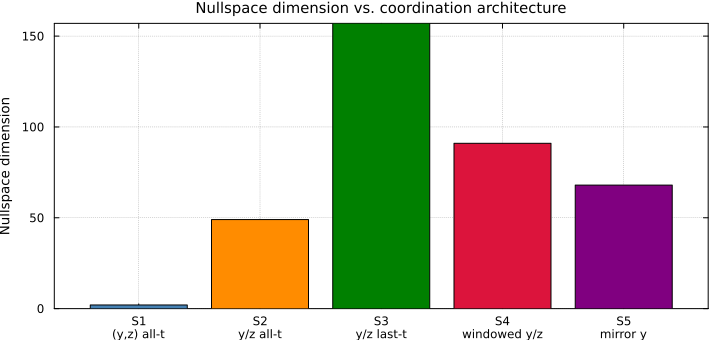

In [14]:
for r in (result1, result2, result3, result4, result5)
    show(stdout, MIME("text/plain"), r); println()
end

bar(["S1\n(y,z) all-t", "S2\ny/z all-t", "S3\ny/z last-t", "S4\nwindowed y/z", "S5\nmirror y"],
    [result1.null_dim, result2.null_dim, result3.null_dim, result4.null_dim, result5.null_dim];
    ylabel = "Nullspace dimension",
    title  = "Nullspace dimension vs. coordination architecture",
    legend = false,
    color  = [:steelblue, :darkorange, :green, :crimson, :purple])